In [1]:
import os
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image, ImageFile
import glob
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import segmentation_models_pytorch as smp



In [2]:
def get_full_dataset():
    DATA_ROOT = "dataset"
    PHASE_ROOT = os.path.join(DATA_ROOT, "phases_16")


    ImageFile.LOAD_TRUNCATED_IMAGES = False

    def safe_loader(path):
        try:
            with open(path, "rb") as f:
                img = Image.open(f)
                return img.convert("RGB")
        except OSError:
            raise

    # 1) transforms (simple to start)
    train_tf = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),  # dataset images are grayscale
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
    ])

    val_tf = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    # 2) dataset from folder structure: phases_16/class_name
    full_ds = datasets.ImageFolder(
        root=PHASE_ROOT,
        transform=train_tf,
        loader=safe_loader,   
    )
    num_classes = len(full_ds.classes)
    print("Classes:", full_ds.classes)
    return full_ds

# 3) train/val split
# val_ratio = 0.3
# n_val = int(len(full_ds) * val_ratio)
# n_train = len(full_ds) - n_val
# train_ds, val_ds = random_split(full_ds, [n_train, n_val])

# # val transforms for val subset
# val_ds.dataset.transform = val_tf

# train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4)
# val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=4)

# # 4) model: simple ResNet18 adapted to 1-channel input
# model = models.resnet18(weights="IMAGENET1K_V1")
# model.conv1.in_channels = 1
# model.conv1.weight = nn.Parameter(model.conv1.weight.mean(dim=1, keepdim=True))  # average RGB to 1 channel
# model.fc = nn.Linear(model.fc.in_features, num_classes)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [3]:
full_ds = get_full_dataset()

Classes: ['t2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tEB', 'tHB', 'tM', 'tPB2', 'tPNa', 'tPNf', 'tSB']


In [4]:


deleted_file_count = 0

print("Beginning Pre-Processing - Check all images in a folder for corruption")
def check_images_in_folder(folder_path):
    """Check all images in a folder for corruption"""
    corrupted_files = []
    valid_files = []
    
    # Get all image files
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff', '*.gif']
    all_files = []
    
    for ext in image_extensions:
        all_files.extend(glob.glob(os.path.join(folder_path, '**', ext), recursive=True))
    
    print(f"Checking {len(all_files)} images...")
    
    for i, file_path in enumerate(all_files):
        try:
            with Image.open(file_path) as img:
                img.verify()  # Check if image is corrupted
            # Re-open to check if it can be loaded completely
            with Image.open(file_path) as img:
                img.load()
            valid_files.append(file_path)
        except Exception as e:           
            corrupted_files.append(file_path)
        
        #if (i + 1) % 100 == 0:
    print(f"Processed {i + 1}/{len(all_files)} images")
    return valid_files, corrupted_files

# Check your dataset
dataset_path = "dataset/phases_16"  # Update this path
valid_files, corrupted_files = check_images_in_folder(dataset_path)

print(f"\nSummary:")
print(f"Valid images: {len(valid_files)}")
print(f"Corrupted images: {len(corrupted_files)}")


#  remove corrupted files
'''if corrupted_files:
    response = input(f"\nFound {len(corrupted_files)} corrupted files. Delete them? (y/n): ")
    if response.lower() == 'y':
        for corrupted_file in corrupted_files:
            try:
                os.remove(corrupted_file)
                deleted_file_count = deleted_file_count + 1
                
            except Exception as e:
                print(f"Could not delete {corrupted_file}: {e}")'''
print(f"Deleted: ", deleted_file_count)

Beginning Pre-Processing - Check all images in a folder for corruption


Checking 266041 images...
Processed 266041/266041 images

Summary:
Valid images: 245899
Corrupted images: 20142
Deleted:  0


In [5]:
dataset_root = "dataset/phases_16"

valid_set = set(valid_files)   

class_to_valid_paths = {}
for class_name in os.listdir(dataset_root):
    class_dir = os.path.join(dataset_root, class_name)
    if not os.path.isdir(class_dir):
        continue

    imgs = []
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tiff", "*.gif"):
        for p in glob.glob(os.path.join(class_dir, ext)):
            if p in valid_set:          # keep only non‑corrupted
                imgs.append(p)

    if imgs:
        class_to_valid_paths[class_name] = imgs

print("Classes:", {k: len(v) for k, v in class_to_valid_paths.items()})


Classes: {'tM': 15584, 't5': 7144, 't4': 7496, 't7': 9886, 't6': 7840, 'tPNa': 39898, 'tEB': 19363, 't9+': 46749, 't3': 4560, 'tHB': 97, 't8': 29983, 'tPNf': 6363, 'tPB2': 8298, 't2': 27264, 'tSB': 15374}


In [6]:
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

class ValidImageDataset(Dataset):
    def __init__(self, class_to_paths, transform=None):
        self.transform = transform
        self.samples = [] 
        self.classes = sorted(class_to_paths.keys())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        for cls in self.classes:
            for p in class_to_paths[cls]:
                self.samples.append((p, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, label

full_ds = ValidImageDataset(class_to_valid_paths, transform=train_tf)


{'t2': 29189, 't3': 5127, 't4': 8177, 't5': 8045, 't6': 8366, 't7': 10531, 't8': 32602, 't9+': 51112, 'tEB': 19535, 'tHB': 97, 'tM': 17084, 'tPB2': 8895, 'tPNa': 43244, 'tPNf': 6793, 'tSB': 17244}


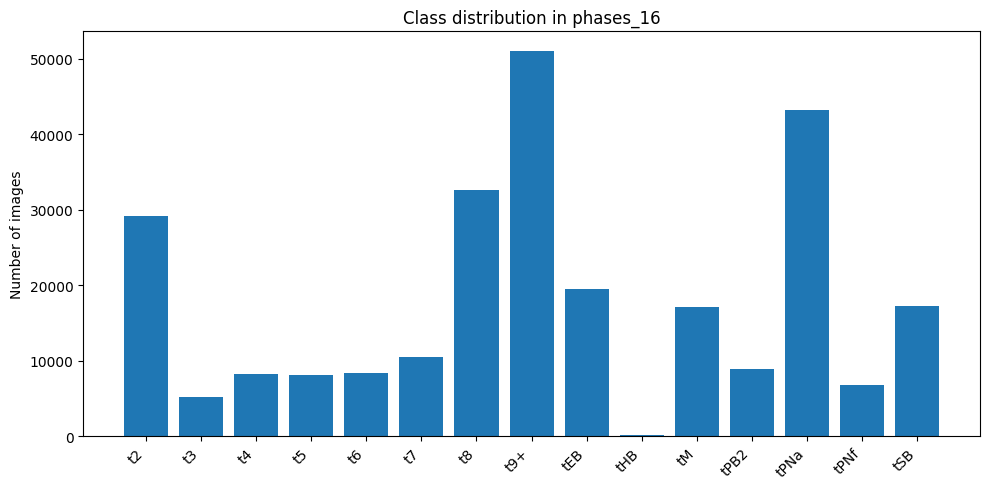

In [7]:
import os
import glob
import matplotlib.pyplot as plt

PHASE_ROOT = "dataset/phases_16"   # root with 16 phase folders

# 1. count images per class
class_counts = {}
image_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tiff", "*.gif")

for class_name in sorted(os.listdir(PHASE_ROOT)):
    class_dir = os.path.join(PHASE_ROOT, class_name)
    if not os.path.isdir(class_dir):
        continue

    count = 0
    for ext in image_exts:
        count += len(glob.glob(os.path.join(class_dir, ext)))
    class_counts[class_name] = count

print(class_counts)

# 2. bar plot
classes = list(class_counts.keys())
counts  = [class_counts[c] for c in classes]

plt.figure(figsize=(10, 5))
plt.bar(classes, counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("Class distribution in phases_16")
plt.tight_layout()
plt.show()


In [8]:
from torch.utils.data import random_split, DataLoader

def get_train_test_dataloader():
    val_ratio = 0.3
    n_val = int(len(full_ds) * val_ratio)
    n_train = len(full_ds) - n_val
    train_ds, val_ds = random_split(full_ds, [n_train, n_val])

    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4)
    val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=4)

    return train_loader, val_loader


In [10]:
train_loader, val_loader = get_train_test_dataloader()

Naive resnet

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----- 1. Naive ResNet18 classifier -----
num_classes = 16  # change if needed

model = models.resnet18(weights="IMAGENET1K_V1")  # pretrained ImageNet
# if your transforms use Grayscale(1), adapt first conv to 1 channel
model.conv1.in_channels = 1
model.conv1.weight = nn.Parameter(model.conv1.weight.mean(dim=1, keepdim=True))
# replace final FC layer with num_classes
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

# ----- 2. Standard cross-entropy + simple optimizer -----
criterion = nn.CrossEntropyLoss()              # no class weights
optimizer = optim.SGD(model.parameters(),      # classic SGD
                      lr=0.01,
                      momentum=0.9,
                      weight_decay=1e-4)
# optional: LR scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer,
                                      step_size=10,
                                      gamma=0.1)

# ----- 3. Training / validation loops -----
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            logits = model(imgs)
            loss = criterion(logits, labels)

            total_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)

    return total_loss / total, correct / total



train_losses, val_losses = [], []
train_accs, val_accs = [], []

num_epochs = 10
for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = eval_epoch(model, val_loader,   criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:02d} | "
          f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f}")


Epoch 01 | train loss 0.8127 acc 0.712 | val loss 0.6448 acc 0.773
Epoch 02 | train loss 0.4477 acc 0.843 | val loss 0.4186 acc 0.855
Epoch 03 | train loss 0.3200 acc 0.888 | val loss 0.3615 acc 0.875
Epoch 04 | train loss 0.2506 acc 0.913 | val loss 0.2840 acc 0.904
Epoch 05 | train loss 0.2045 acc 0.928 | val loss 0.2753 acc 0.910
Epoch 06 | train loss 0.1701 acc 0.941 | val loss 0.2598 acc 0.917
Epoch 07 | train loss 0.1482 acc 0.948 | val loss 0.2613 acc 0.918
Epoch 08 | train loss 0.1304 acc 0.955 | val loss 0.2449 acc 0.921
Epoch 09 | train loss 0.1148 acc 0.961 | val loss 0.2235 acc 0.929
Epoch 10 | train loss 0.1034 acc 0.965 | val loss 0.2492 acc 0.921


accuracy and loss curves:

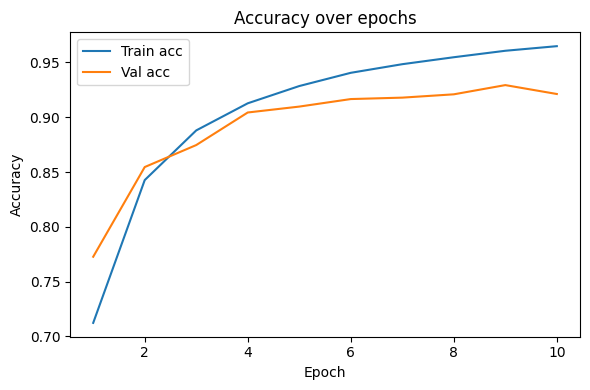

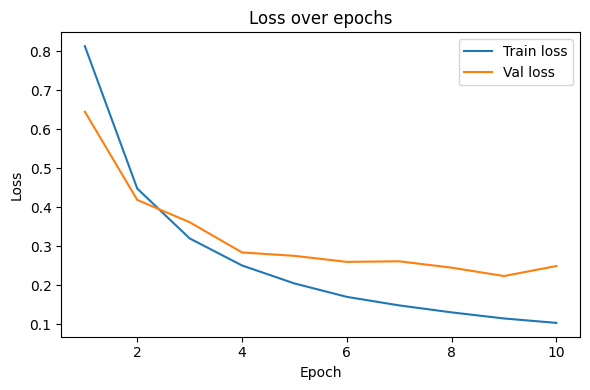

In [12]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, train_accs, label="Train acc")
plt.plot(epochs, val_accs,   label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over epochs")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over epochs")
plt.legend()
plt.tight_layout()
plt.show()


classification report:

In [13]:
phase_names = [
    "tPB2", "tPNa", "tPNf",
    "t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+",
    "tM", "tSB", "tB", "tEB", "tHB"
]

def get_all_preds(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs  = imgs.to(device)
            logits = model(imgs)
            preds  = logits.argmax(1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.numpy())
    return np.concatenate(all_labels), np.concatenate(all_preds)

y_true, y_pred = get_all_preds(model, val_loader, device)

print(classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(phase_names)),   # ensure all 16 are reported
    target_names=phase_names,
    digits=4,
    zero_division=0
))


              precision    recall  f1-score   support

        tPB2     0.9554    0.9563    0.9558      8123
        tPNa     0.8067    0.8219    0.8142      1325
        tPNf     0.9742    0.8817    0.9256      2223
          t2     0.7923    0.8951    0.8406      2106
          t3     0.7760    0.8809    0.8251      2410
          t4     0.8828    0.8343    0.8578      2933
          t5     0.9449    0.9350    0.9399      8945
          t6     0.9451    0.9464    0.9457     14042
          t7     0.9878    0.9593    0.9733      5821
          t8     0.9444    0.9444    0.9444        36
         t9+     0.8344    0.8683    0.8510      4693
          tM     0.9210    0.7821    0.8459      2474
         tSB     0.9612    0.9594    0.9603     12038
          tB     0.7127    0.9068    0.7981      1857
         tEB     0.9259    0.8636    0.8936      4743
         tHB     0.0000    0.0000    0.0000         0

   micro avg     0.9202    0.9202    0.9202     73769
   macro avg     0.8353   

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


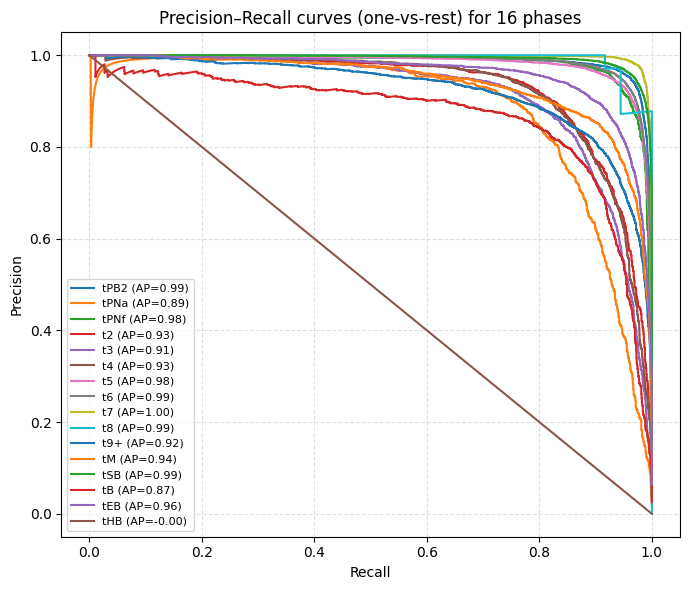

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

phase_names = [
    "tPB2", "tPNa", "tPNf",
    "t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+",
    "tM", "tSB", "tB", "tEB", "tHB"
]
num_classes = len(phase_names)

# ---- 1. Collect true labels and prediction scores (probabilities) ----
def get_probs_and_labels(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(imgs)                  # (N, 16)
            probs  = torch.softmax(logits, dim=1) # convert to probabilities
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_labels), np.concatenate(all_probs)

y_true, y_prob = get_probs_and_labels(model, val_loader, device)
# y_true: (N,), y_prob: (N, 16)

# ---- 2. Binarize labels for one-vs-rest PR curves ----
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
# shape: (N, 16)

# ---- 3. Compute and plot per-class PR curves ----
plt.figure(figsize=(7, 6))

for c in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, c], y_prob[:, c])
    ap = average_precision_score(y_true_bin[:, c], y_prob[:, c])
    plt.plot(recall, precision, lw=1.5,
             label=f"{phase_names[c]} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curves (one-vs-rest) for 16 phases")
plt.legend(fontsize=8, loc="best")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [15]:
# import torch
# from sklearn.metrics import confusion_matrix

# def get_confusion_matrix(model, loader, device, num_classes=16):
#     model.eval()
#     all_preds = []
#     all_labels = []

#     with torch.no_grad():
#         for imgs, labels in loader:
#             imgs = imgs.to(device)
#             labels = labels.to(device)

#             logits = model(imgs)
#             preds = logits.argmax(dim=1)

#             all_preds.append(preds.cpu())
#             all_labels.append(labels.cpu())

#     all_preds = torch.cat(all_preds).numpy()
#     all_labels = torch.cat(all_labels).numpy()

#     cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
#     return cm


In [16]:
# cm = get_confusion_matrix(model, val_loader, device, num_classes=16)
# print(cm)


In [17]:


def get_confusion_matrix_and_log(model, loader, device,
                                 num_classes=15,
                                 class_names=None,
                                 log_path="eval_log.txt"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            logits = model(imgs)
            preds = logits.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    cm = confusion_matrix(all_labels, all_preds,
                          labels=list(range(num_classes)))
    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names if class_names is not None else None,
        digits=4
    )

    # ---- write to log file ----
    with open(log_path, "a") as f:
        f.write("\n" + "="*80 + "\n")
        f.write("Evaluation log\n")
        f.write("="*80 + "\n\n")

        f.write("Confusion matrix (rows=true, cols=pred):\n")
        np.savetxt(f, cm, fmt="%d")
        f.write("\n\nClassification report:\n")
        f.write(report)
        f.write("\n\n")

    return cm, report


In [18]:
phase_names = [
    "tPB2", "tPNa", "tPNf",
    "t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+",
    "tM", "tSB", "tB", "tEB"
]

cm, report = get_confusion_matrix_and_log(
    model,
    val_loader,
    device,
    num_classes=15,
    class_names=phase_names,
    log_path="resnet18_val_eval.log"
)


In [19]:
# print(cm, report)

UNet++

In [20]:
# pip install segmentation-models-pytorch==0.3.3
# pip install timm  # required backend


In [21]:
# DATA_ROOT = "dataset/phases_16"

# train_tf = transforms.Compose([
#     transforms.Grayscale(num_output_channels=1),
#     transforms.Resize((256, 256)),
#     transforms.RandomHorizontalFlip(),
#     transforms.ToTensor(),
# ])

# val_tf = transforms.Compose([
#     transforms.Grayscale(num_output_channels=1),
#     transforms.Resize((256, 256)),
#     transforms.ToTensor(),
# ])

# full_ds = datasets.ImageFolder(root=DATA_ROOT, transform=train_tf)
# num_classes = len(full_ds.classes)

# val_ratio = 0.3
# n_val = int(len(full_ds) * val_ratio)
# n_train = len(full_ds) - n_val
# train_ds, val_ds = random_split(full_ds, [n_train, n_val])
# val_ds.dataset.transform = val_tf

# train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=4)
# val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=4)


In [22]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # UNet++ with ResNet18 encoder, 1‑channel input, no segmentation classes
# unetpp = smp.UnetPlusPlus(
#     encoder_name="resnet18",        # backbone [web:127]
#     encoder_weights="imagenet",
#     in_channels=1,                  # grayscale
#     classes=0,                      # no seg output; we use encoder features
# )

# # classification head on top of encoder output
# class UNetPPClassifier(nn.Module):
#     def __init__(self, backbone, num_classes):
#         super().__init__()
#         self.backbone = backbone
#         # get encoder output channels from SMP metadata
#         enc_channels = self.backbone.encoder.out_channels[-1]
#         self.pool = nn.AdaptiveAvgPool2d(1)
#         self.fc = nn.Linear(enc_channels, num_classes)

#     def forward(self, x):
#         # encoder returns list of feature maps at multiple scales
#         feats = self.backbone.encoder(x)
#         x = feats[-1]               # deepest feature map
#         x = self.pool(x).flatten(1)
#         x = self.fc(x)
#         return x

# model = UNetPPClassifier(unetpp, num_classes).to(device)

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [23]:
# def train_epoch(model, loader, optimizer, criterion, device):
#     model.train()
#     total_loss, correct, total = 0.0, 0, 0
#     for batch_idx, (imgs, labels) in enumerate(loader):
#         try:
#             imgs, labels = imgs.to(device), labels.to(device)

#             optimizer.zero_grad()
#             logits = model(imgs)
#             loss = criterion(logits, labels)
#             loss.backward()
#             optimizer.step()

#             total_loss += loss.item() * imgs.size(0)
#             preds = logits.argmax(1)
#             correct += (preds == labels).sum().item()
#             total += imgs.size(0)

#         except OSError as e:
#             # e.g. "image file is truncated" – skip this batch
#             print(f"[WARN] Skipping corrupted batch {batch_idx}: {e}")
#             continue

#     return (total_loss / total if total > 0 else 0.0,
#             correct / total if total > 0 else 0.0)


# def eval_epoch(model, loader, criterion, device):
#     model.eval()
#     total_loss, correct, total = 0.0, 0, 0
#     with torch.no_grad():
#         for batch_idx, (imgs, labels) in enumerate(loader):
#             try:
#                 imgs, labels = imgs.to(device), labels.to(device)
#                 logits = model(imgs)
#                 loss = criterion(logits, labels)

#                 total_loss += loss.item() * imgs.size(0)
#                 preds = logits.argmax(1)
#                 correct += (preds == labels).sum().item()
#                 total += imgs.size(0)

#             except OSError as e:
#                 print(f"[WARN] Skipping corrupted val batch {batch_idx}: {e}")
#                 continue

#     return (total_loss / total if total > 0 else 0.0,
#             correct / total if total > 0 else 0.0)


# for epoch in range(1, 10):
#     tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
#     va_loss, va_acc = eval_epoch(model, val_loader, criterion, device)
#     print(f"Epoch {epoch:02d} | train {tr_loss:.4f}/{tr_acc:.3f} "
#           f"| val {va_loss:.4f}/{va_acc:.3f}")


Renset with imagenet and weighted cross entropy, adam optimizer

In [24]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# DATA_ROOT = "dataset/phases_16"

# train_tf = transforms.Compose([
#     transforms.Grayscale(num_output_channels=1),
#     transforms.Resize((256, 256)),
#     transforms.RandomHorizontalFlip(),
#     transforms.ToTensor(),
# ])

# val_tf = transforms.Compose([
#     transforms.Grayscale(num_output_channels=1),
#     transforms.Resize((256, 256)),
#     transforms.ToTensor(),
# ])

# full_ds = datasets.ImageFolder(root=DATA_ROOT, transform=train_tf)

full_ds = get_full_dataset()
num_classes = len(full_ds.classes)

train_loader, val_loader = get_train_test_dataloader()


# val_ratio = 0.3
# n_val = int(len(full_ds) * val_ratio)
# n_train = len(full_ds) - n_val
# train_ds, val_ds = random_split(full_ds, [n_train, n_val])
# val_ds.dataset.transform = val_tf

# train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=4)
# val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=4)


Classes: ['t2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tEB', 'tHB', 'tM', 'tPB2', 'tPNa', 'tPNf', 'tSB']


In [25]:
from collections import Counter
import torch
import torch.nn as nn
from torchvision import models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- compute class weights from dataset labels ---
targets = [y for _, y in full_ds.samples]          # integer labels
counts = Counter(targets)
num_classes = len(full_ds.classes)
total = len(targets)

# inverse-frequency weights
weights = []
for c in range(num_classes):
    weights.append(total / counts[c])

class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
class_weights = class_weights / class_weights.max()   # optional normalization

# --- model as before ---
model = models.resnet18(weights="IMAGENET1K_V1")
model.conv1.in_channels = 1
model.conv1.weight = nn.Parameter(model.conv1.weight.mean(dim=1, keepdim=True))
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# --- weighted cross-entropy + optimizer ---
criterion = nn.CrossEntropyLoss(weight=class_weights)   # <--- weighted CE
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,          # typical starting LR for Adam with pretrained nets
    weight_decay=1e-4 # L2 regularization
)


In [26]:

# # --- tell Pillow to accept truncated images ---
# ImageFile.LOAD_TRUNCATED_IMAGES = True  # <--- add here

# # --- dataset / loaders (use safe loader if you want) ---
# def safe_loader(path):
#     try:
#         with open(path, "rb") as f:
#             img = Image.open(f)
#             return img.convert("L")  # or "RGB"
#     except OSError:
#         return Image.new("L", (224, 224), color=0)

# full_ds = datasets.ImageFolder(root=DATA_ROOT,
#                                transform=train_tf,
#                                loader=safe_loader)


full_ds = get_full_dataset()

Classes: ['t2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tEB', 'tHB', 'tM', 'tPB2', 'tPNa', 'tPNf', 'tSB']


In [27]:
# from torch.utils.data import random_split, DataLoader

# val_ratio = 0.3
# n_val = int(len(full_ds) * val_ratio)
# n_train = len(full_ds) - n_val
# train_ds, val_ds = random_split(full_ds, [n_train, n_val])

# train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4)
# val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=4)

train_loader, val_loader = get_train_test_dataloader()


In [ ]:
# def train_epoch(model, loader, optimizer, criterion, device):
#     model.train()
#     total_loss, correct, total = 0.0, 0, 0
#     for imgs, labels in loader:
#         imgs, labels = imgs.to(device), labels.to(device)
#         optimizer.zero_grad()
#         logits = model(imgs)
#         loss = criterion(logits, labels)
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item() * imgs.size(0)
#         preds = logits.argmax(1)
#         correct += (preds == labels).sum().item()
#         total += imgs.size(0)
#     return total_loss / total, correct / total

# def eval_epoch(model, loader, criterion, device):
#     model.eval()
#     total_loss, correct, total = 0.0, 0, 0
#     with torch.no_grad():
#         for imgs, labels in loader:
#             imgs, labels = imgs.to(device), labels.to(device)
#             logits = model(imgs)
#             loss = criterion(logits, labels)
#             total_loss += loss.item() * imgs.size(0)
#             preds = logits.argmax(1)
#             correct += (preds == labels).sum().item()
#             total += imgs.size(0)
#     return total_loss / total, correct / total

# for epoch in range(1, 5):
#     tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
#     va_loss, va_acc = eval_epoch(model, val_loader, criterion, device)
#     print(f"Epoch {epoch:02d} | train acc {tr_acc:.3f} | val acc {va_acc:.3f}")


In [40]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np


def get_confusion_matrix_and_log(model, loader, device,
                                 num_classes=15,
                                 class_names=None,
                                 log_path="eval_log.txt"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    cm = confusion_matrix(
        all_labels,
        all_preds,
        labels=list(range(num_classes))
    )

    # ---------------- format confusion matrix with x/y labels ----------------
    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]

    # header row: empty cell + predicted labels
    header = ["true\\pred"] + class_names
    cm_with_labels = np.zeros((num_classes + 1, num_classes + 1), dtype=object)
    cm_with_labels[0, :] = header
    cm_with_labels[1:, 0] = class_names
    cm_with_labels[1:, 1:] = cm

    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )

    with open(log_path, "a") as f:
        f.write("\n" + "=" * 80 + "\n")
        f.write("Evaluation log\n")
        f.write("=" * 80 + "\n\n")

        f.write("Confusion matrix (rows=true, cols=pred):\n")
        # save as tab‑separated so strings and ints are preserved
        np.savetxt(f, cm_with_labels, fmt="%s", delimiter="\t")
        f.write("\n\nClassification report:\n")
        f.write(report)
        f.write("\n\n")

    return cm, report


In [41]:
phase_names = [
    "tPB2", "tPNa", "tPNf",
    "t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+",
    "tM", "tSB", "tB", "tEB"
]

cm, report = get_confusion_matrix_and_log(
    model,
    val_loader,
    device,
    num_classes=15,
    class_names=phase_names,
    log_path="resnet18_val_eval.log"
)


In [21]:
# print(cm, report)

[[ 8240   129    20    11     6     2     1     2     1     0     7     0
    114   196     1]
 [  169  1348    22    21    11     0     0     0     0     0     1     0
      1     3     0]
 [   57    53  2190    17     8     4     2     1     0     0     0     0
      0     0     0]
 [   29    82    80  2019   169     8    11     3     3     0     6     0
      0     1     0]
 [   20    17    31   119  2207    77    44    13     1     0     7     0
      0     1     0]
 [   15     6     4    36   231  2675   106    49     0     0    16     0
      0     0     5]
 [    6     1     8    19   180   186  9024   240     1     0    54     0
      1     1     6]
 [    1     1     0     6    45    46   244 14132    24     0   872     0
      0     0    80]
 [    0     0     0     0     0     0     0     6  5848     0    15     0
      0     0    23]
 [    0     0     0     0     0     0     0     0     6    25     0     0
      1     0     0]
 [    3     0     0     0     3     2     4    98 

1) Temporal / neighbour‑aware soft labels


1.1 Soft‑label generator

In [26]:
def make_soft_labels(y, num_classes, alpha=0.3):
    """
    y: (N,) int64 tensor of class indices
    returns: (N, C) float tensor, each row sums to 1
    alpha: smoothing toward neighbours (0 = one-hot)
    """
    N = y.size(0)
    C = num_classes
    y_soft = torch.zeros(N, C, device=y.device)

    for i in range(N):
        c = y[i].item()
        # base prob for correct class
        main_p = 1.0 - alpha
        y_soft[i, c] += main_p

        # distribute alpha to neighbours (c-1, c+1) if they exist
        neighbours = []
        if c - 1 >= 0:
            neighbours.append(c - 1)
        if c + 1 < C:
            neighbours.append(c + 1)

        if neighbours:
            share = alpha / len(neighbours)
            for nb in neighbours:
                y_soft[i, nb] += share
    return y_soft


1.2 Soft‑label loss (KL‑divergence)


In [27]:
import torch.nn as nn

soft_criterion = nn.KLDivLoss(reduction="batchmean")  # expects log-probs vs probs

def soft_ce_loss(logits, labels_int, alpha=0.3, num_classes=16):
    """
    logits: (N, C)
    labels_int: (N,) int64
    """
    log_probs = torch.log_softmax(logits, dim=1)
    target_probs = make_soft_labels(labels_int, num_classes, alpha=alpha)
    return soft_criterion(log_probs, target_probs)


1.3 Training / eval loops using soft labels


In [28]:
def train_epoch_soft(model, loader, optimizer, device, alpha=0.3):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = soft_ce_loss(logits, labels, alpha=alpha, num_classes=num_classes)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    return total_loss / total, correct / total

def eval_epoch_soft(model, loader, device, alpha=0.0):
    # alpha=0.0 -> effectively standard CE for reporting
    model.eval()
    ce = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss = ce(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total


1.4 Run training with soft labels


In [29]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

num_epochs = 5
for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train_epoch_soft(model, train_loader, optimizer, device, alpha=0.3)
    va_loss, va_acc = eval_epoch_soft(model, val_loader, device)
    print(f"[Soft] Epoch {epoch:02d} | train acc {tr_acc:.3f} | val acc {va_acc:.3f}")


[Soft] Epoch 01 | train acc 0.696 | val acc 0.688
[Soft] Epoch 02 | train acc 0.826 | val acc 0.834
[Soft] Epoch 03 | train acc 0.878 | val acc 0.877
[Soft] Epoch 04 | train acc 0.906 | val acc 0.879
[Soft] Epoch 05 | train acc 0.924 | val acc 0.907


In [30]:
# import torch
# from sklearn.metrics import confusion_matrix, classification_report
# import numpy as np


# def get_confusion_matrix_and_log(model, loader, device,
#                                  num_classes=15,
#                                  class_names=None,
#                                  log_path="eval_log.txt"):
#     model.eval()
#     all_preds, all_labels = [], []

#     with torch.no_grad():
#         for imgs, labels in loader:
#             imgs, labels = imgs.to(device), labels.to(device)
#             logits = model(imgs)
#             preds = logits.argmax(dim=1)
#             all_preds.append(preds.cpu())
#             all_labels.append(labels.cpu())

#     all_preds = torch.cat(all_preds).numpy()
#     all_labels = torch.cat(all_labels).numpy()

#     cm = confusion_matrix(
#         all_labels,
#         all_preds,
#         labels=list(range(num_classes))
#     )

#     # ---------------- format confusion matrix with x/y labels ----------------
#     if class_names is None:
#         class_names = [str(i) for i in range(num_classes)]

#     # header row: empty cell + predicted labels
#     header = ["true\\pred"] + class_names
#     cm_with_labels = np.zeros((num_classes + 1, num_classes + 1), dtype=object)
#     cm_with_labels[0, :] = header
#     cm_with_labels[1:, 0] = class_names
#     cm_with_labels[1:, 1:] = cm

#     report = classification_report(
#         all_labels,
#         all_preds,
#         target_names=class_names,
#         digits=4
#     )

#     with open(log_path, "a") as f:
#         f.write("\n" + "=" * 80 + "\n")
#         f.write("Evaluation log\n")
#         f.write("=" * 80 + "\n\n")

#         f.write("Confusion matrix (rows=true, cols=pred):\n")
#         # save as tab‑separated so strings and ints are preserved
#         np.savetxt(f, cm_with_labels, fmt="%s", delimiter="\t")
#         f.write("\n\nClassification report:\n")
#         f.write(report)
#         f.write("\n\n")

#     return cm, report


In [31]:
phase_names = [
    "tPB2", "tPNa", "tPNf",
    "t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+",
    "tM", "tSB", "tB", "tEB"
]

cm, report = get_confusion_matrix_and_log(
    model,
    val_loader,
    device,
    num_classes=15,
    class_names=phase_names,
    log_path="resnet18_val_eval.log"
)


In [32]:
print(cm, report)

[[ 8219   283    27    14    25    13     0     0     1     0     0     0
     17    70     0]
 [  160  1165   122    30    22    12     4     0     0     0     0     0
      0     0     0]
 [   11    69  2383    39    33     2     5     1     0     0     0     0
      0     0     0]
 [    9    32   125  1801   450    31    10     2     0     0     0     0
      0     0     0]
 [    6     2    21    67  2173   194    47     7     0     0     0     0
      0     0     0]
 [    2     1     1     9   242  2720   168    23     0     0     1     0
      0     0     0]
 [    1     0    10     6    62   545  8978   256     3     0    17     0
      0     0     0]
 [    2     0     0     1    24    95   564 14208    63     1   299     0
      1     2    45]
 [    0     0     0     0     0     0     0     5  5767     4     8     0
      0     0    90]
 [    0     0     0     0     0     0     0     1     5    18     0     0
      0     0     0]
 [   15     2     1     0    11    25    32   393 

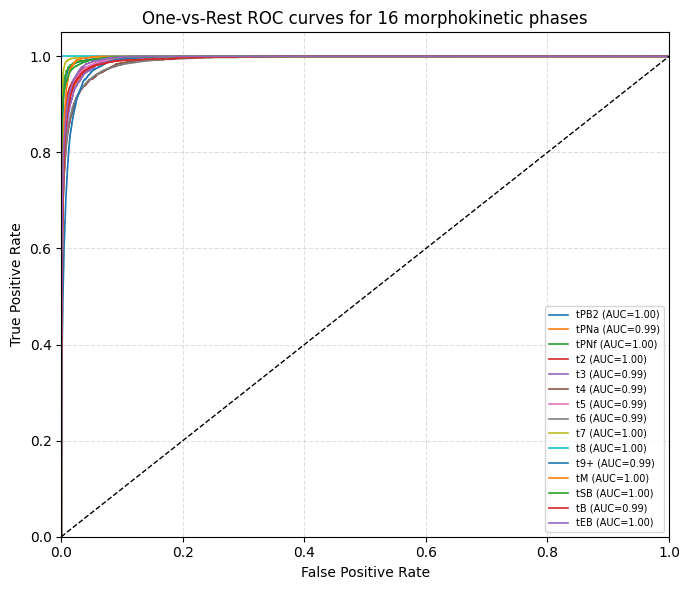

In [42]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

num_classes = 15
phase_names = [
    "tPB2", "tPNa", "tPNf",
    "t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+",
    "tM", "tSB", "tB", "tEB", "tHB"
]

# 1. Collect true labels and predicted probabilities
def get_probs_and_labels(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(imgs)                    # (N, C)
            probs = torch.softmax(logits, dim=1)    # probabilities
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_labels), np.concatenate(all_probs)

y_true, y_prob = get_probs_and_labels(model, val_loader, device)
# y_true: (N,), y_prob: (N, 16)

# 2. Binarize labels for OvR ROC
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
# shape: (N, 16)

# 3. Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot all ROC curves
plt.figure(figsize=(7, 6))
for i in range(num_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        lw=1.2,
        label=f"{phase_names[i]} (AUC={roc_auc[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], "k--", lw=1)  # chance line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC curves for 16 morphokinetic phases")
plt.legend(fontsize=7, loc="lower right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
